---
# XGBoost

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from scipy.sparse import issparse
import xgboost as xgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# ==========================================
# 1. 데이터 로드 및 타겟 변수 변환
# ==========================================
df_clean = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data_team7.csv')

# Attrition(퇴사여부)를 0과 1로 변환
df_clean['Attrition'] = df_clean['Attrition'].map({'Yes': 1, 'No': 0})

# 특성(X)과 타겟(y) 분리
X_clean = df_clean.drop('Attrition', axis=1)
y_clean = df_clean['Attrition']

print("Loaded\nData Shape:", df_clean.shape)

Loaded
Data Shape: (1470, 31)


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

def get_hr_data(filepath, model_type='tree'):
    """
    model_type: 'linear_xgb' (원-핫 인코딩) 또는 'lgbm_tabnet' (오디널 인코딩)
    """
    # 1. 데이터 로드 및 Feature / Target 분리
    df = pd.read_csv(filepath)
    target_col = 'Attrition'

    X = df.drop(target_col, axis=1)
    # Target이 'Yes'/'No'라면 1/0으로 변환
    y = df[target_col].apply(lambda x: 1 if x == 'Yes' else 0) if df[target_col].dtype == 'object' else df[target_col]

    # 2. 공정성을 위한 고정된 분할 (70:15:15)
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
    X_valid, X_test, y_valid, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

    # 3. 변수 타입별 분류
    categorical_cols = ['BusinessTravel', 'Department','EducationField','Gender', 'JobRole', 'MaritalStatus', 'OverTime', ]
    numerical_cols = ['Age', 'DailyRate', 'DistanceFromHome', 'Education','EnvironmentSatisfaction','HourlyRate','JobInvolvement','JobLevel','JobSatisfaction','MonthlyIncome', 'MonthlyRate', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

    # 4. 모델 타입에 따른 전처리기(ColumnTransformer) 구성
    if model_type == 'linear_xgb':
        # Track A: 다중공선성 방지를 위해 drop='first' 적용
        cat_transformer = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
    else:
        # Track B: 단순 정수 변환
        cat_transformer = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numerical_cols),
            ('cat', cat_transformer, categorical_cols)
        ]
    )

    # 5. 전처리 적용
    X_train_processed = preprocessor.fit_transform(X_train)
    X_valid_processed = preprocessor.transform(X_valid)
    X_test_processed = preprocessor.transform(X_test)

    return X_train_processed, X_valid_processed, X_test_processed, y_train, y_valid, y_test

In [ ]:
X_train, X_valid, X_test, y_train, y_valid, y_test = get_hr_data(filepath='/content/drive/MyDrive/Colab Notebooks/data_team7.csv', model_type='linear_xgb')

# ==========================================
# 3. XGBoost 모델 구현 및 학습
# ==========================================
# 타겟 불균형 비율 계산 (퇴사자가 비퇴사자보다 훨씬 적기 때문에 가중치 부여)
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# 모델 객체 생성
model_xgb = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    max_depth=4,
    learning_rate=0.05,
    n_estimators=300,
    scale_pos_weight=pos_weight, # 타겟 불균형 처리
    random_state=42
)

# 학습
model_xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from scipy.sparse import issparse
import xgboost as xgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, average_precision_score, log_loss

# ==========================================
# 4. 학습 결과 평가 및 지표 확인
# ==========================================
# 예측 클래스 (0 또는 1)
y_pred = model_xgb.predict(X_test)
# 예측 확률 (ROC-AUC 등에 사용, 두번째 열이 1(Yes)이 될 확률)
y_pred_proba = model_xgb.predict_proba(X_test)[:, 1]

# 평가 지표 계산
# 각 sklearn.metrics 함수에 (실제값, 예측값)을 넣어 계산합니다.
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)
pr_auc = average_precision_score(y_test, y_pred_proba) # PR AUC 추가
logloss = log_loss(y_test, y_pred_proba)
cm = confusion_matrix(y_test, y_pred)


print("="*70)
print(" XGBoost 최종 평가 지표")
print("="*70)
print(f"▶ 정확도 (Accuracy)  : {acc:.4f} (전체 예측 중 정답 비율)")
print(f"▶ 정밀도 (Precision) : {prec:.4f} ('퇴사'라고 예측한 사람 중 실제 퇴사자 비율)")
print(f"▶ 재현율 (Recall)    : {rec:.4f} (실제 퇴사자 중 모델이 잡아낸 비율)")
print(f"▶ F1-Score           : {f1:.4f} (정밀도와 재현율의 조화평균)")
print(f"▶ ROC-AUC            : {auc:.4f} (전반적인 분류 성능, 1에 가까울수록 우수)")
print(f"▶ PR-AUC             : {pr_auc:.4f} (정밀도-재현율 곡선 아래 면적)") # PR AUC 출력 추가
print(f"▶ LogLoss            : {logloss:.4f} (로그 손실: 작을수록 우수)")
print("="*70)
print("\n[오차 행렬 (Confusion Matrix)]")
print(pd.DataFrame(cm,
                   index=['실제 유지(0)', '실제 퇴사(1)'],
                   columns=['예측 유지(0)', '예측 퇴사(1)']))
print("\n* 설명: 우리는 '퇴사할 사람'을 미리 찾아내는 것이 중요하므로, '재현율(Recall)'을 유심히 봐야 합니다.")

 XGBoost 최종 평가 지표
▶ 정확도 (Accuracy)  : 0.8462 (전체 예측 중 정답 비율)
▶ 정밀도 (Precision) : 0.5500 ('퇴사'라고 예측한 사람 중 실제 퇴사자 비율)
▶ 재현율 (Recall)    : 0.3056 (실제 퇴사자 중 모델이 잡아낸 비율)
▶ F1-Score           : 0.3929 (정밀도와 재현율의 조화평균)
▶ ROC-AUC            : 0.7488 (전반적인 분류 성능, 1에 가까울수록 우수)
▶ PR-AUC             : 0.4781 (정밀도-재현율 곡선 아래 면적)
▶ LogLoss            : 0.4095 (로그 손실: 작을수록 우수)

[오차 행렬 (Confusion Matrix)]
          예측 유지(0)  예측 퇴사(1)
실제 유지(0)       176         9
실제 퇴사(1)        25        11

* 설명: 우리는 '퇴사할 사람'을 미리 찾아내는 것이 중요하므로, '재현율(Recall)'을 유심히 봐야 합니다.


# ==========================================
# 5. 변수 중요도 (Feature Importance) 시각화
# ==========================================

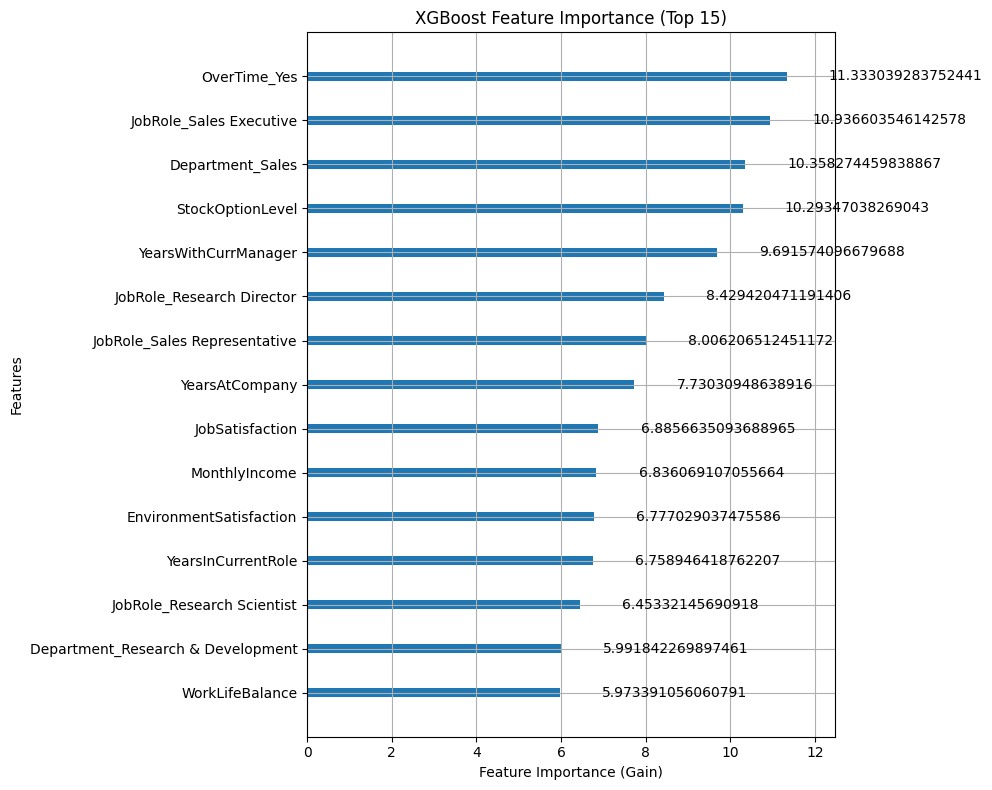

In [ ]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import xgboost as xgb

# Define numerical and categorical column names as used in get_hr_data
categorical_cols = ['BusinessTravel', 'Department','EducationField','Gender', 'JobRole', 'MaritalStatus', 'OverTime']
numerical_cols = ['Age', 'DailyRate', 'DistanceFromHome', 'Education','EnvironmentSatisfaction','HourlyRate','JobInvolvement','JobLevel','JobSatisfaction','MonthlyIncome', 'MonthlyRate', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

# Align with variable names used in the original cell's logic
num_cols = numerical_cols
cat_cols = categorical_cols

# Recreate the categorical transformer as used in get_hr_data for 'linear_xgb'
cat_transformer = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)

# Recreate the preprocessor
reconstructed_preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', cat_transformer, cat_cols)
    ]
)

# Fit the preprocessor on X_clean (the full unprocessed DataFrame available in the kernel state)
# This is crucial for `named_transformers_` to be populated.
reconstructed_preprocessor.fit(X_clean)

# 1. ColumnTransformer에서 원-핫 인코딩된 범주형 특성 이름 추출
cat_encoder = reconstructed_preprocessor.named_transformers_['cat']
cat_feature_names = cat_encoder.get_feature_names_out(cat_cols)

# 2. 수치형 특성과 범주형 특성 이름 결합
feature_names = num_cols + cat_feature_names.tolist()

# 3. XGBoost 모델에 특성 이름 매핑
model_xgb.get_booster().feature_names = feature_names

# 4. 시각화 (상위 15개 변수)
fig, ax = plt.subplots(figsize=(10, 8))
xgb.plot_importance(
    model_xgb,
    max_num_features=15,
    importance_type='gain', # 정보 이득(Gain) 기준
    ax=ax,
    title='XGBoost Feature Importance (Top 15)',
    xlabel='Feature Importance (Gain)',
    ylabel='Features'
)
plt.tight_layout()
plt.show()

### [추가] 의사결정 나무(Decision Tree) 내부 구조 시각화 (원본 수치 기준)
사람이 직관적으로 이해하기 쉽도록, 수치형 변수를 스케일링하지 않은 원본 데이터로 가벼운 시각화용 모델을 만들어 첫 번째 트리(`num_trees=0`)의 판단 기준을 확인해 봅니다.

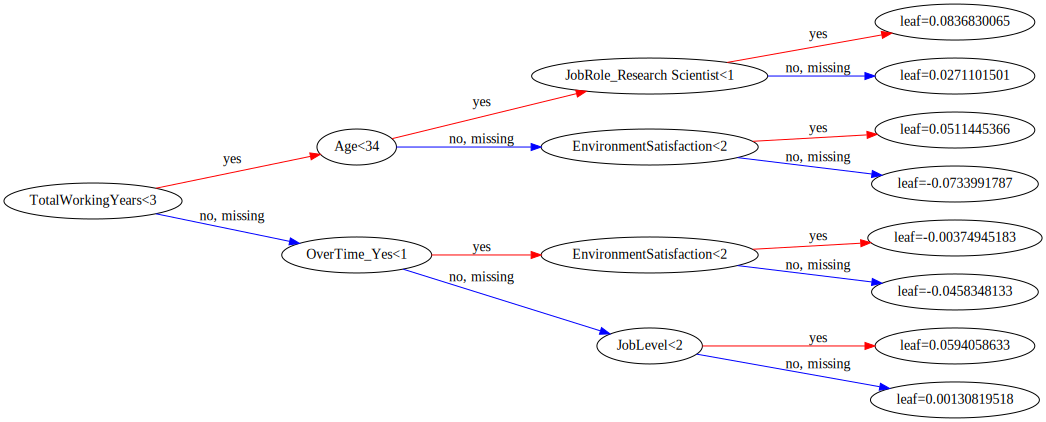

양수(+)로 클수록: 퇴사할 가능성(Yes)이 높다는 것을 의미
음수(-)로 작을수록: 퇴사하지 않고 유지할 가능성(No)이 높다는 것을 의미


In [ ]:
import xgboost as xgb
import graphviz
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

# 1. 수치형 데이터는 스케일링하지 않고(passthrough), 범주형만 인코딩하는 시각화용 전처리기 생성
preprocessor_unscaled = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_cols)
    ]
)

# 2. 전처리 적용 및 데이터 분할
X_unscaled = preprocessor_unscaled.fit_transform(X_clean)
X_train_un, X_test_un, y_train_un, y_test_un = train_test_split(
    X_unscaled, y_clean, test_size=0.2, stratify=y_clean, random_state=42
)

# 3. 시각화용 모델 학습 (보기 편하게 깊이를 3으로 제한)
model_xgb_vis = xgb.XGBClassifier(
    objective='binary:logistic',
    max_depth=3,
    learning_rate=0.05,
    n_estimators=10, # 트리를 많이 만들 필요 없이 구조만 확인
    scale_pos_weight=pos_weight,
    random_state=42
)
model_xgb_vis.fit(X_train_un, y_train_un)

# 4. 피처 이름 매핑 (트리 노드에 변수명이 제대로 나오도록 설정)
cat_encoder_un = preprocessor_unscaled.named_transformers_['cat']
cat_feature_names_un = cat_encoder_un.get_feature_names_out(cat_cols)
feature_names_un = num_cols + cat_feature_names_un.tolist()
model_xgb_vis.get_booster().feature_names = feature_names_un

# 5. 첫 번째 트리 시각화
graph = xgb.to_graphviz(model_xgb_vis, tree_idx=0, rankdir='LR')
display(graph)
print("양수(+)로 클수록: 퇴사할 가능성(Yes)이 높다는 것을 의미\n음수(-)로 작을수록: 퇴사하지 않고 유지할 가능성(No)이 높다는 것을 의미")

# ==========================================
# 6. 하이퍼파라미터 튜닝 (GridSearchCV)
# ==========================================

In [ ]:
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import make_scorer, log_loss, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
import xgboost as xgb
import pandas as pd

# Definition of get_hr_data moved here to ensure it's defined
def get_hr_data(filepath, model_type='tree'):
    """
    model_type: 'linear_xgb' (원-핫 인코딩) 또는 'lgbm_tabnet' (오디널 인코딩)
    """
    # 1. 데이터 로드 및 Feature / Target 분리
    df = pd.read_csv(filepath)
    target_col = 'Attrition'

    X = df.drop(target_col, axis=1)
    # Target이 'Yes'/'No'라면 1/0으로 변환
    y = df[target_col].apply(lambda x: 1 if x == 'Yes' else 0) if df[target_col].dtype == 'object' else df[target_col]

    # 2. 공정성을 위한 고정된 분할 (70:15:15)
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
    X_valid, X_test, y_valid, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

    # 3. 변수 타입별 분류
    categorical_cols = ['BusinessTravel', 'Department','EducationField','Gender', 'JobRole', 'MaritalStatus', 'OverTime', ]
    numerical_cols = ['Age', 'DailyRate', 'DistanceFromHome', 'Education','EnvironmentSatisfaction','HourlyRate','JobInvolvement','JobLevel','JobSatisfaction','MonthlyIncome', 'MonthlyRate', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

    # 4. 모델 타입에 따른 전처리기(ColumnTransformer) 구성
    if model_type == 'linear_xgb':
        # Track A: 다중공선성 방지를 위해 drop='first' 적용
        cat_transformer = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
    else:
        # Track B: 단순 정수 변환
        cat_transformer = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numerical_cols),
            ('cat', cat_transformer, categorical_cols)
        ]
    )

    # 5. 전처리 적용
    X_train_processed = preprocessor.fit_transform(X_train)
    X_valid_processed = preprocessor.transform(X_valid)
    X_test_processed = preprocessor.transform(X_test)

    return X_train_processed, X_valid_processed, X_test_processed, y_train, y_valid, y_test


# Call get_hr_data to load and split the data
X_train, X_valid, X_test, y_train, y_valid, y_test = get_hr_data(filepath='/content/drive/MyDrive/Colab Notebooks/data_team7.csv', model_type='linear_xgb')

# Calculate pos_weight
# 타겟 불균형 비율 계산 (퇴사자가 비퇴사자보다 훨씬 적기 때문에 가중치 부여)
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# 1. 탐색할 파라미터 조합 설정
param_grid = {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200, 300]
}

# Define multiple scoring metrics
scoring_metrics = {
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
    'pr_auc': 'average_precision',
    'log_loss': make_scorer(log_loss, greater_is_better=False, needs_proba=True) # LogLoss requires probabilities and should be minimized
}

# 2. GridSearchCV 객체 생성
# -> '퇴사할 사람을 잘 잡아내는 것'이 중요하므로 refit='recall'로 설정
grid_search = GridSearchCV(
    estimator=xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss', # For early stopping or internal use
        scale_pos_weight=pos_weight, # 타겟 불균형 처리는 유지
        random_state=42
    ),
    param_grid=param_grid,
    scoring=scoring_metrics,
    refit='recall', # 최적의 모델 선택 기준
    cv=3,      # 3겹 교차 검증
    n_jobs=-1, # 모든 CPU 코어 사용
    verbose=1
)

# 3. 튜닝 실행
grid_search.fit(X_train, y_train)

print("\n[최적의 하이퍼파라미터]")
print(grid_search.best_params_)

# 4. 찾은 최적의 모델로 재평가
best_xgb = grid_search.best_estimator_

y_pred_tuned = best_xgb.predict(X_test)
y_pred_proba_tuned = best_xgb.predict_proba(X_test)[:, 1]

print("\n" + "="*40)
print(" 튜닝 후 XGBoost 평가 지표 (최적화 모델)")
print("="*40)
print(f"▶ 정확도 (Accuracy)  : {accuracy_score(y_test, y_pred_tuned):.4f}")
print(f"▶ 정밀도 (Precision) : {precision_score(y_test, y_pred_tuned):.4f}")
print(f"▶ 재현율 (Recall)    : {recall_score(y_test, y_pred_tuned):.4f}  <-- 변화 확인!")
print(f"▶ F1-Score           : {f1_score(y_test, y_pred_tuned):.4f}")
print(f"▶ ROC-AUC            : {roc_auc_score(y_test, y_pred_proba_tuned):.4f}")
print(f"▶ PR-AUC             : {average_precision_score(y_test, y_pred_proba_tuned):.4f}")
print(f"▶ LogLoss            : {log_loss(y_test, y_pred_proba_tuned):.4f}") # LogLoss for probabilities

print("="*40)


Fitting 3 folds for each of 27 candidates, totalling 81 fits

[최적의 하이퍼파라미터]
{'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200}

 튜닝 후 XGBoost 평가 지표 (최적화 모델)
▶ 정확도 (Accuracy)  : 0.7873
▶ 정밀도 (Precision) : 0.3778
▶ 재현율 (Recall)    : 0.4722  <-- 변화 확인!
▶ F1-Score           : 0.4198
▶ ROC-AUC            : 0.7715
▶ PR-AUC             : 0.4515
▶ LogLoss            : 0.5199


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan]
  warnings.warn(


## 6.1 하이퍼파라미터 튜닝 (RandomizedSearchCV)

**GridSearchCV**는 모든 하이퍼파라미터 조합을 탐색하지만, 탐색 공간이 커지면 비효율적입니다.

**RandomizedSearchCV**는 주어진 분포에서 무작위로 샘플링하여 하이퍼파라미터를 탐색합니다. 모든 조합을 탐색하지 않으므로 시간이 훨씬 적게 걸리면서도, 대부분 Grid Search와 유사하거나 더 나은 결과를 얻을 수 있습니다. 특히, 각 하이퍼파라미터가 모델 성능에 미치는 영향이 불균형할 때 더욱 효과적입니다.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

# 1. 탐색할 파라미터 분포 설정 (GridSearch의 param_grid와는 다름)
# 'max_depth': 정수형 범위, 'learning_rate': 균등 분포, 'n_estimators': 정수형 범위
param_distributions = {
    'max_depth': randint(3, 6), # 3, 4, 5 중 랜덤 선택
    'learning_rate': uniform(0.01, 0.1 - 0.01), # 0.01부터 0.1까지 균등 분포
    'n_estimators': randint(100, 301) # 100부터 300까지 랜덤 선택
}

# 2. RandomizedSearchCV 객체 생성
random_search = RandomizedSearchCV(
    estimator=xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        scale_pos_weight=pos_weight,
        random_state=42
    ),
    param_distributions=param_distributions,
    n_iter=20, # 시도할 샘플링 횟수 (GridSearch의 조합 수보다 적게 설정)
    scoring=scoring_metrics, # GridSearch와 동일한 지표 사용
    refit='recall',
    cv=3,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

# 3. 튜닝 실행
random_search.fit(X_train, y_train)

print("\n[RandomizedSearch 최적의 하이퍼파라미터]")
print(random_search.best_params_)

# 4. 찾은 최적의 모델로 재평가
best_xgb_random = random_search.best_estimator_

y_pred_tuned_random = best_xgb_random.predict(X_test)
y_pred_proba_tuned_random = best_xgb_random.predict_proba(X_test)[:, 1]

print("\n" + "="*40)
print(" RandomizedSearch 후 XGBoost 평가 지표 (최적화 모델)")
print("="*40)
print(f"▶ 정확도 (Accuracy)  : {accuracy_score(y_test, y_pred_tuned_random):.4f}")
print(f"▶ 정밀도 (Precision) : {precision_score(y_test, y_pred_tuned_random):.4f}")
print(f"▶ 재현율 (Recall)    : {recall_score(y_test, y_pred_tuned_random):.4f}")
print(f"▶ F1-Score           : {f1_score(y_test, y_pred_tuned_random):.4f}")
print(f"▶ ROC-AUC            : {roc_auc_score(y_test, y_pred_proba_tuned_random):.4f}")
print(f"▶ PR-AUC             : {average_precision_score(y_test, y_pred_proba_tuned_random):.4f}")
print(f"▶ LogLoss            : {log_loss(y_test, y_pred_proba_tuned_random):.4f}")

print("="*40)


Fitting 3 folds for each of 20 candidates, totalling 60 fits

[RandomizedSearch 최적의 하이퍼파라미터]
{'learning_rate': np.float64(0.01007008892569129), 'max_depth': 3, 'n_estimators': 260}

 RandomizedSearch 후 XGBoost 평가 지표 (최적화 모델)
▶ 정확도 (Accuracy)  : 0.7828
▶ 정밀도 (Precision) : 0.3696
▶ 재현율 (Recall)    : 0.4722
▶ F1-Score           : 0.4146
▶ ROC-AUC            : 0.7703
▶ PR-AUC             : 0.4575
▶ LogLoss            : 0.5012


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan]
  warnings.warn(


## 6.2 하이퍼파라미터 튜닝 (Bayesian Optimization)

**베이즈 최적화(Bayesian Optimization)**는 이전 시도에서 얻은 정보를 바탕으로 다음 탐색할 하이퍼파라미터 조합을 예측하여 효율적으로 최적의 값을 찾아가는 방법입니다. 이는 무작위 탐색보다 더 적은 시도로 더 좋은 성능을 보이는 경우가 많습니다. `scikit-optimize` 라이브러리의 `BayesSearchCV`를 사용하여 구현할 수 있습니다.

In [ ]:
# scikit-optimize 라이브러리 설치
!pip install scikit-optimize

In [ ]:
from skopt import BayesSearchCV
from skopt.space import Real, Integer
from sklearn.metrics import log_loss # Ensure log_loss is imported

# Custom log_loss scorer function
def custom_log_loss_scorer(estimator, X, y_true):
    y_pred_proba = estimator.predict_proba(X)[:, 1]
    # Return negative log_loss because BayesSearchCV maximizes the score
    return -log_loss(y_true, y_pred_proba)

# 1. 탐색할 파라미터 공간 정의
# Real은 실수형, Integer는 정수형 분포를 나타냅니다.
param_spaces = {
    'max_depth': Integer(3, 5), # 3에서 5 사이의 정수
    'learning_rate': Real(0.01, 0.1, 'log-uniform'), # 0.01에서 0.1 사이의 로그-균등 분포
    'n_estimators': Integer(100, 300) # 100에서 300 사이의 정수
}

# Update scoring_metrics to use the custom log_loss scorer
scoring_metrics_bayes = {
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
    'pr_auc': 'average_precision',
    'log_loss': custom_log_loss_scorer # Use the custom function here
}

# 2. BayesSearchCV 객체 생성
# n_iter는 최적화를 수행할 반복 횟수입니다.
bayes_search = BayesSearchCV(
    estimator=xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        scale_pos_weight=pos_weight,
        random_state=42
    ),
    search_spaces=param_spaces,
    n_iter=20, # 시도할 샘플링 횟수 (RandomSearch와 동일하게 설정)
    scoring=scoring_metrics_bayes, # Use the updated scoring_metrics
    refit='recall',
    cv=3,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

# 3. 튜닝 실행
bayes_search.fit(X_train, y_train)

print("\n[Bayesian Optimization 최적의 하이퍼파라미터]")
print(bayes_search.best_params_)

# 4. 찾은 최적의 모델로 재평가
best_xgb_bayes = bayes_search.best_estimator_

y_pred_tuned_bayes = best_xgb_bayes.predict(X_test)
y_pred_proba_tuned_bayes = best_xgb_bayes.predict_proba(X_test)[:, 1]

print("\n" + "="*40)
print(" Bayesian Optimization 후 XGBoost 평가 지표 (최적화 모델)")
print("="*40)
print(f"▶ 정확도 (Accuracy)  : {accuracy_score(y_test, y_pred_tuned_bayes):.4f}")
print(f"▶ 정밀도 (Precision) : {precision_score(y_test, y_pred_tuned_bayes):.4f}")
print(f"▶ 재현율 (Recall)    : {recall_score(y_test, y_pred_tuned_bayes):.4f}")
print(f"▶ F1-Score           : {f1_score(y_test, y_pred_tuned_bayes):.4f}")
print(f"▶ ROC-AUC            : {roc_auc_score(y_test, y_pred_proba_tuned_bayes):.4f}")
print(f"▶ PR-AUC             : {average_precision_score(y_test, y_pred_proba_tuned_bayes):.4f}")
# Note: When using custom_log_loss_scorer for `scoring`, best_score_ will be negative log_loss
# but for evaluation metrics, we print the positive log_loss.
print(f"▶ LogLoss            : {log_loss(y_test, y_pred_proba_tuned_bayes):.4f}")

print("="*40)

Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fi

In [ ]:
# Optuna 라이브러리 설치
!pip install optuna

## 6.3 하이퍼파라미터 튜닝 (Optuna)

**Optuna**는 동적으로 탐색 공간을 정의하고, 이전 시도의 결과를 바탕으로 다음 시도를 효율적으로 결정하는 현대적인 하이퍼파라미터 최적화 프레임워크입니다. 특히, 병렬 처리가 용이하며 다양한 샘플링 알고리즘(예: Tree-structured Parzen Estimator, TPE)을 제공하여 Bayesian Optimization과 유사하게 효율적인 최적화가 가능합니다.

여기서는 PR-AUC(Precision-Recall AUC)를 최대화하는 방향으로 하이퍼파라미터 튜닝을 진행합니다. PR-AUC는 불균형 데이터셋에서 모델의 성능을 평가하는 데 특히 유용합니다. `n_trials`를 높게 설정하여 더 많은 탐색을 통해 최적의 하이퍼파라미터를 찾도록 하겠습니다.

In [ ]:
import optuna
from sklearn.metrics import average_precision_score
import xgboost as xgb

# Optuna 최적화 objective 함수 정의
def objective(trial):
    # 1. 탐색할 하이퍼파라미터 공간 정의
    max_depth = trial.suggest_int('max_depth', 3, 5)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.1, log=True) # Changed to suggest_float with log=True
    n_estimators = trial.suggest_int('n_estimators', 100, 300)

    # 2. XGBoost 모델 생성 및 학습
    model = xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        max_depth=max_depth,
        learning_rate=learning_rate,
        n_estimators=n_estimators,
        scale_pos_weight=pos_weight, # 타겟 불균형 처리
        random_state=42
    )
    model.fit(X_train, y_train)

    # 3. 검증 데이터셋으로 PR-AUC 계산 (최대화 목표)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    pr_auc = average_precision_score(y_test, y_pred_proba)

    return pr_auc

In [ ]:
# Optuna Study 생성 및 최적화 실행
# n_trials는 탐색할 하이퍼파라미터 조합의 수입니다. (높게 설정)
study = optuna.create_study(direction='maximize') # PR-AUC를 최대화하는 방향으로 설정
study.optimize(objective, n_trials=100) # 더 많은 시도를 위해 n_trials를 높게 설정

print("\n[Optuna 최적의 하이퍼파라미터]")
print(study.best_trial.params) # Corrected to study.best_trial.params

# 4. 찾은 최적의 모델로 재평가
best_xgb_optuna = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    **study.best_trial.params, # Corrected to study.best_trial.params
    scale_pos_weight=pos_weight,
    random_state=42
)
best_xgb_optuna.fit(X_train, y_train)

y_pred_tuned_optuna = best_xgb_optuna.predict(X_test)
y_pred_proba_tuned_optuna = best_xgb_optuna.predict_proba(X_test)[:, 1]

print("\n" + "="*40)
print(" Optuna 후 XGBoost 평가 지표 (최적화 모델)")
print("="*40)
print(f"▶ 정확도 (Accuracy)  : {accuracy_score(y_test, y_pred_tuned_optuna):.4f}")
print(f"▶ 정밀도 (Precision) : {precision_score(y_test, y_pred_tuned_optuna):.4f}")
print(f"▶ 재현율 (Recall)    : {recall_score(y_test, y_pred_tuned_optuna):.4f}")
print(f"▶ F1-Score           : {f1_score(y_test, y_pred_tuned_optuna):.4f}")
print(f"▶ ROC-AUC            : {roc_auc_score(y_test, y_pred_proba_tuned_optuna):.4f}")
print(f"▶ PR-AUC             : {average_precision_score(y_test, y_pred_proba_tuned_optuna):.4f}")
print(f"▶ LogLoss            : {log_loss(y_test, y_pred_proba_tuned_optuna):.4f}")

print("="*40)

[I 2026-05-30 07:47:15,395] A new study created in memory with name: no-name-08b0325f-44ab-4bac-8b61-0e51e1f5d731
[I 2026-05-30 07:47:15,533] Trial 0 finished with value: 0.4740875583553915 and parameters: {'max_depth': 5, 'learning_rate': 0.0317051603518937, 'n_estimators': 275}. Best is trial 0 with value: 0.4740875583553915.
[I 2026-05-30 07:47:15,582] Trial 1 finished with value: 0.4723512984311211 and parameters: {'max_depth': 4, 'learning_rate': 0.022788486274057357, 'n_estimators': 112}. Best is trial 0 with value: 0.4740875583553915.
[I 2026-05-30 07:47:15,733] Trial 2 finished with value: 0.4776777791750759 and parameters: {'max_depth': 5, 'learning_rate': 0.010987839449685476, 'n_estimators': 261}. Best is trial 2 with value: 0.4776777791750759.
[I 2026-05-30 07:47:15,867] Trial 3 finished with value: 0.5090756731267297 and parameters: {'max_depth': 4, 'learning_rate': 0.044754032133774685, 'n_estimators': 118}. Best is trial 3 with value: 0.5090756731267297.
[I 2026-05-30 07


[Optuna 최적의 하이퍼파라미터]
{'max_depth': 5, 'learning_rate': 0.092801602756172, 'n_estimators': 253}

 Optuna 후 XGBoost 평가 지표 (최적화 모델)
▶ 정확도 (Accuracy)  : 0.8643
▶ 정밀도 (Precision) : 0.6667
▶ 재현율 (Recall)    : 0.3333
▶ F1-Score           : 0.4444
▶ ROC-AUC            : 0.7779
▶ PR-AUC             : 0.5324
▶ LogLoss            : 0.4632


# scikit-optimize 설치 (Colab에 없을 수 있으므로 설치 명령 포함)
!pip install scikit-optimize

In [ ]:
from skopt import BayesSearchCV
from skopt.space import Real, Integer
from sklearn.metrics import log_loss # Ensure log_loss is imported

# Custom log_loss scorer function
def custom_log_loss_scorer(estimator, X, y_true):
    y_pred_proba = estimator.predict_proba(X)[:, 1]
    # Return negative log_loss because BayesSearchCV maximizes the score
    return -log_loss(y_true, y_pred_proba)

# 1. 탐색할 파라미터 공간 정의
# Real은 실수형, Integer는 정수형 분포를 나타냅니다.
param_spaces = {
    'max_depth': Integer(3, 5), # 3에서 5 사이의 정수
    'learning_rate': Real(0.01, 0.1, 'log-uniform'), # 0.01에서 0.1 사이의 로그-균등 분포
    'n_estimators': Integer(100, 300) # 100에서 300 사이의 정수
}

# Update scoring_metrics to use the custom log_loss scorer
scoring_metrics_bayes = {
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
    'pr_auc': 'average_precision',
    'log_loss': custom_log_loss_scorer # Use the custom function here
}

# 2. BayesSearchCV 객체 생성
# n_iter는 최적화를 수행할 반복 횟수입니다.
bayes_search = BayesSearchCV(
    estimator=xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        scale_pos_weight=pos_weight,
        random_state=42
    ),
    search_spaces=param_spaces,
    n_iter=20, # 시도할 샘플링 횟수 (RandomSearch와 동일하게 설정)
    scoring=scoring_metrics_bayes, # Use the updated scoring_metrics
    refit='recall',
    cv=3,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

# 3. 튜닝 실행
bayes_search.fit(X_train, y_train)

print("\n[Bayesian Optimization 최적의 하이퍼파라미터]")
print(bayes_search.best_params_)

# 4. 찾은 최적의 모델로 재평가
best_xgb_bayes = bayes_search.best_estimator_

y_pred_tuned_bayes = best_xgb_bayes.predict(X_test)
y_pred_proba_tuned_bayes = best_xgb_bayes.predict_proba(X_test)[:, 1]

print("\n" + "="*40)
print(" Bayesian Optimization 후 XGBoost 평가 지표 (최적화 모델)")
print("="*40)
print(f"▶ 정확도 (Accuracy)  : {accuracy_score(y_test, y_pred_tuned_bayes):.4f}")
print(f"▶ 정밀도 (Precision) : {precision_score(y_test, y_pred_tuned_bayes):.4f}")
print(f"▶ 재현율 (Recall)    : {recall_score(y_test, y_pred_tuned_bayes):.4f}")
print(f"▶ F1-Score           : {f1_score(y_test, y_pred_tuned_bayes):.4f}")
print(f"▶ ROC-AUC            : {roc_auc_score(y_test, y_pred_proba_tuned_bayes):.4f}")
print(f"▶ PR-AUC             : {average_precision_score(y_test, y_pred_proba_tuned_bayes):.4f}")
# Note: When using custom_log_loss_scorer for `scoring`, best_score_ will be negative log_loss
# but for evaluation metrics, we print the positive log_loss.
print(f"▶ LogLoss            : {log_loss(y_test, y_pred_proba_tuned_bayes):.4f}")

print("="*40)


Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fi

## 7. 고급 특성 공학 (Advanced Feature Engineering)

모델의 성능을 향상시키기 위해 기존 특성들을 조합하여 새로운 특성을 생성합니다. 예를 들어, 만족도 점수들을 합산하거나, 근무 기간 대비 소득 비율 등을 계산할 수 있습니다. 이는 모델이 데이터에서 더 복잡한 패턴을 학습하는 데 도움을 줄 수 있습니다.


In [ ]:
def apply_advanced_feature_engineering(df):
    df_new = df.copy()

    # 1. 종합 만족도 점수 (Total Satisfaction Score)
    # 여러 만족도 지표를 합산하여 직원의 전반적인 만족도를 나타내는 지표를 생성합니다.
    df_new['Total_Satisfaction_Score'] = (
        df_new['EnvironmentSatisfaction'] +
        df_new['JobSatisfaction'] +
        df_new['RelationshipSatisfaction'] +
        df_new['WorkLifeBalance']
    )

    # 2. 근무 연차 대비 소득 지표 (Income_Per_WorkingYear, Income_Per_YearAtCompany)
    # 근무 기간 대비 월급 수준을 파악하여 소득 성장률이나 직무 만족도와 연관된 지표를 만듭니다.
    df_new['Income_Per_WorkingYear'] = df_new['MonthlyIncome'] / (df_new['TotalWorkingYears'] + 1) # +1은 분모가 0이 되는 것을 방지
    df_new['Income_Per_YearAtCompany'] = df_new['MonthlyIncome'] / (df_new['YearsAtCompany'] + 1)

    # 3. 직급 대비 소득 (Income_Per_Level)
    # 직급이 높을수록 소득이 증가하는 경향이 있으나, 그 비율이 적정한지 파악하는 지표입니다.
    df_new['Income_Per_Level'] = df_new['MonthlyIncome'] / df_new['JobLevel']

    # 4. 비용 효율성 (Cost_Effectiveness)
    # 성과 평가 대비 연봉 인상률을 통해 회사의 보상 정책 효율성을 가늠할 수 있습니다.
    df_new['Cost_Effectiveness'] = df_new['PercentSalaryHike'] / df_new['PerformanceRating']

    # 5. 번아웃 위험 (Burnout_Risk)
    # 초과 근무 여부와 워크라이프 밸런스를 결합하여 번아웃 위험을 나타내는 지표를 생성합니다.
    is_overtime = df_new['OverTime'].apply(lambda x: 1 if x == 'Yes' or x == 1 else 0)
    wlb_reversed = 5 - df_new['WorkLifeBalance'] # WorkLifeBalance는 높을수록 좋으므로, 낮을수록 번아웃 위험이 높은 것으로 변환
    df_new['Burnout_Risk'] = is_overtime + wlb_reversed

    # 6. 만족도-워라밸 상호작용 (Sat_WLB_Interaction)
    # 전반적인 만족도와 워라밸의 곱을 통해 두 요소의 시너지를 탐색합니다.
    df_new['Sat_WLB_Interaction'] = df_new['Total_Satisfaction_Score'] * df_new['WorkLifeBalance']

    # 7. 승진 속도 지수 (Promotion_Speed_Index)
    # 총 근무 연차 대비 직급 상승 속도를 나타내어 경력 개발 기회를 파악합니다.
    df_new['Promotion_Speed_Index'] = df_new['JobLevel'] / (df_new['TotalWorkingYears'] + 1)

    # 8. 정체 지수 (Stagnation_Index)
    # 회사 재직 기간 대비 마지막 승진 이후 경과 연수를 통해 정체도를 측정합니다.
    df_new['Stagnation_Index'] = df_new['YearsSinceLastPromotion'] / (df_new['YearsAtCompany'] + 1)

    # 9. 이직 지수 (Job_Hopping_Index)
    # 총 근무 연차 대비 이직 횟수를 통해 이직 성향을 파악합니다.
    df_new['Job_Hopping_Index'] = df_new['NumCompaniesWorked'] / (df_new['TotalWorkingYears'] + 1)

    # 10. 회사 충성도 비율 (Loyalty_Ratio)
    # 총 근무 연차 대비 현재 회사 재직 연수를 통해 직원의 충성도를 나타냅니다.
    df_new['Loyalty_Ratio'] = np.where(
        df_new['TotalWorkingYears'] > 0,
        df_new['YearsAtCompany'] / df_new['TotalWorkingYears'],
        0
    )

    return df_new

In [ ]:
import pandas as pd
import numpy as np

# Ensure df_clean is loaded and preprocessed for feature engineering
# This code is duplicated from an earlier cell (8e80fba7) to ensure execution in case of kernel state loss.
df_clean = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data_team7.csv')
df_clean['Attrition'] = df_clean['Attrition'].map({'Yes': 1, 'No': 0})

# 원본 데이터프레임 'df_clean'에 특성 공학 적용
df_engineered = apply_advanced_feature_engineering(df_clean)

print("Original Data Shape:", df_clean.shape)
print("Engineered Data Shape:", df_engineered.shape)

# 새로운 특성들이 추가되었는지 확인
display(df_engineered.head())

Original Data Shape: (1470, 31)
Engineered Data Shape: (1470, 42)


,Attrition,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,Income_Per_WorkingYear,Income_Per_YearAtCompany,Income_Per_Level,Cost_Effectiveness,Burnout_Risk,Sat_WLB_Interaction,Promotion_Speed_Index,Stagnation_Index,Job_Hopping_Index,Loyalty_Ratio
0,1,41,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,665.888889,856.142857,2996.5,3.666667,5,8,0.222222,0.000000,0.888889,0.750000
1,0,49,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,466.363636,466.363636,2565.0,5.750000,2,36,0.181818,0.090909,0.090909,1.000000
2,1,37,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,261.250000,2090.000000,2090.0,5.000000,3,36,0.125000,0.000000,0.750000,0.000000
3,0,33,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,323.222222,323.222222,2909.0,3.666667,3,39,0.111111,0.333333,0.111111,1.000000
4,0,27,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,495.428571,1156.000000,3468.0,4.000000,2,30,0.142857,0.666667,1.285714,0.333333


## 8. 새로운 특성을 포함한 모델 재학습

고급 특성 공학을 통해 추가된 11개의 새로운 변수들을 포함하여 모델을 다시 학습하고, 이전 모델과 성능을 비교해 봅니다.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import xgboost as xgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, log_loss, confusion_matrix

# 1. 특성(X)과 타겟(y) 분리
X_eng = df_engineered.drop('Attrition', axis=1)
y_eng = df_engineered['Attrition']

# 2. 데이터 분할 (70:15:15)
X_train_eng, X_temp_eng, y_train_eng, y_temp_eng = train_test_split(X_eng, y_eng, test_size=0.3, stratify=y_eng, random_state=42)
X_valid_eng, X_test_eng, y_valid_eng, y_test_eng = train_test_split(X_temp_eng, y_temp_eng, test_size=0.5, stratify=y_temp_eng, random_state=42)

# 3. 변수 타입별 분류 (새로운 특성들은 모두 수치형으로 취급)
categorical_cols = ['BusinessTravel', 'Department','EducationField','Gender', 'JobRole', 'MaritalStatus', 'OverTime']
numerical_cols_eng = [col for col in X_eng.columns if col not in categorical_cols]

# 4. 전처리기 구성 및 적용
preprocessor_eng = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols_eng),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), categorical_cols)
    ]
)

X_train_eng_proc = preprocessor_eng.fit_transform(X_train_eng)
X_valid_eng_proc = preprocessor_eng.transform(X_valid_eng)
X_test_eng_proc = preprocessor_eng.transform(X_test_eng)

# 5. XGBoost 모델 학습 (기본 하이퍼파라미터 사용)
pos_weight_eng = (y_train_eng == 0).sum() / (y_train_eng == 1).sum()

model_xgb_eng = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    max_depth=4,
    learning_rate=0.05,
    n_estimators=300,
    scale_pos_weight=pos_weight_eng,
    random_state=42
)

model_xgb_eng.fit(X_train_eng_proc, y_train_eng)
print("모델 학습 완료!")

모델 학습 완료!


In [ ]:
# 6. 모델 평가
y_pred_eng = model_xgb_eng.predict(X_test_eng_proc)
y_pred_proba_eng = model_xgb_eng.predict_proba(X_test_eng_proc)[:, 1]

acc_eng = accuracy_score(y_test_eng, y_pred_eng)
prec_eng = precision_score(y_test_eng, y_pred_eng)
rec_eng = recall_score(y_test_eng, y_pred_eng)
f1_eng = f1_score(y_test_eng, y_pred_eng)
auc_eng = roc_auc_score(y_test_eng, y_pred_proba_eng)
pr_auc_eng = average_precision_score(y_test_eng, y_pred_proba_eng)
logloss_eng = log_loss(y_test_eng, y_pred_proba_eng)
cm_eng = confusion_matrix(y_test_eng, y_pred_eng)

print("="*70)
print(" [특성 공학 적용 후] XGBoost 평가 지표")
print("="*70)
print(f"▶ 정확도 (Accuracy)  : {acc_eng:.4f}")
print(f"▶ 정밀도 (Precision) : {prec_eng:.4f}")
print(f"▶ 재현율 (Recall)    : {rec_eng:.4f}")
print(f"▶ F1-Score           : {f1_eng:.4f}")
print(f"▶ ROC-AUC            : {auc_eng:.4f}")
print(f"▶ PR-AUC             : {pr_auc_eng:.4f}")
print(f"▶ LogLoss            : {logloss_eng:.4f}")
print("="*70)
print("\n[오차 행렬 (Confusion Matrix)]")
print(pd.DataFrame(cm_eng,
                   index=['실제 유지(0)', '실제 퇴사(1)'],
                   columns=['예측 유지(0)', '예측 퇴사(1)']))

 [특성 공학 적용 후] XGBoost 평가 지표
▶ 정확도 (Accuracy)  : 0.8190
▶ 정밀도 (Precision) : 0.4333
▶ 재현율 (Recall)    : 0.3611
▶ F1-Score           : 0.3939
▶ ROC-AUC            : 0.7414
▶ PR-AUC             : 0.4680
▶ LogLoss            : 0.4472

[오차 행렬 (Confusion Matrix)]
          예측 유지(0)  예측 퇴사(1)
실제 유지(0)       168        17
실제 퇴사(1)        23        13
